In [1]:
# Import the tools we need
from statsbombpy import sb    # to pull the second competition's data
import pandas as pd           # for our data tables
import numpy as np            # for the distance/angle math
import ast                    # to parse the location coordinates

# First, let's remind ourselves which competitions are available
competitions = sb.competitions()   # get the list again

# Show competitions that would make a good CONTRAST to La Liga
# We'll look at a few interesting ones: World Cup, Champions League, etc.
competitions[['competition_id', 'season_id', 'country_name',
              'competition_name', 'season_name']].head(20)

C:\Users\User\anaconda3\envs\xg\Lib\site-packages\statsbombpy\api_client.py:23: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,competition_id,season_id,country_name,competition_name,season_name
0,9,281,Germany,1. Bundesliga,2023/2024
1,9,27,Germany,1. Bundesliga,2015/2016
2,1267,107,Africa,African Cup of Nations,2023
3,16,4,Europe,Champions League,2018/2019
4,16,1,Europe,Champions League,2017/2018
5,16,2,Europe,Champions League,2016/2017
6,16,27,Europe,Champions League,2015/2016
7,16,26,Europe,Champions League,2014/2015
8,16,25,Europe,Champions League,2013/2014
9,16,24,Europe,Champions League,2012/2013


In [2]:
# ---- PULL THE SECOND LEAGUE: Bundesliga 2015/16 (our TEST league) ----
# competition_id=9 is Bundesliga, season_id=27 is 2015/16 (same season as our La Liga data)

# Get all the matches in that Bundesliga season
bundesliga_matches = sb.matches(competition_id=9, season_id=27)

# Print how many matches (Bundesliga has 18 teams, so ~306 matches expected)
print("Bundesliga matches:", bundesliga_matches.shape[0])

# ---- Extract all shots from those matches (same as we did for La Liga in Phase 1) ----
all_shots = []                                    # empty list to collect shots
match_ids = bundesliga_matches['match_id'].tolist()  # get every match id

# Loop through each match and pull its shots
for i, mid in enumerate(match_ids):
    try:
        events = sb.events(match_id=mid)              # get all events in the match
        shots = events[events['type'] == 'Shot']      # keep only the shots
        all_shots.append(shots)                       # add them to our list
    except Exception as e:
        print(f"Skipped match {mid}: {e}")            # skip any match that errors

    if (i + 1) % 50 == 0:                             # progress update every 50 matches
        print(f"Processed {i + 1}/{len(match_ids)} matches...")

# Stack all the Bundesliga shots into one table
bundesliga_shots = pd.concat(all_shots, ignore_index=True)
print("\nTotal Bundesliga shots:", bundesliga_shots.shape[0])

C:\Users\User\anaconda3\envs\xg\Lib\site-packages\statsbombpy\api_client.py:23: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


Bundesliga matches: 34


C:\Users\User\anaconda3\envs\xg\Lib\site-packages\statsbombpy\api_client.py:23: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
C:\Users\User\anaconda3\envs\xg\Lib\site-packages\statsbombpy\api_client.py:23: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
C:\Users\User\anaconda3\envs\xg\Lib\site-packages\statsbombpy\api_client.py:23: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
C:\Users\User\anaconda3\envs\xg\Lib\site-packages\statsbombpy\api_client.py:23: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
C:\Users\User\anaconda3\envs\xg\Lib\site-packages\statsbombpy\api_client.py:23: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
C:\Users\User\anaconda3\envs\xg\Lib\site-packages\statsbombpy\api_client.py:23: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
C:\Users\U


Total Bundesliga shots: 840


In [3]:
# ---- Apply the SAME feature engineering we used on La Liga (from Phase 2) ----
# It must be identical, or the comparison isn't fair.

# First make our target column: 1 if goal, 0 if not
bundesliga_shots['goal'] = (bundesliga_shots['shot_outcome'] == 'Goal').astype(int)

# Parse the location text back into [x, y] numbers
# (some may already be lists, so we handle both cases)
bundesliga_shots['location_parsed'] = bundesliga_shots['location'].apply(
    lambda loc: ast.literal_eval(loc) if isinstance(loc, str) else loc
)

# Split into x and y coordinates
bundesliga_shots['x'] = bundesliga_shots['location_parsed'].apply(lambda loc: loc[0])
bundesliga_shots['y'] = bundesliga_shots['location_parsed'].apply(lambda loc: loc[1])

# ---- Distance to goal (same Pythagoras formula as before) ----
x_dist = 120 - bundesliga_shots['x']                       # gap to goal line
y_dist = (bundesliga_shots['y'] - 40).abs()                # gap from centre
bundesliga_shots['distance'] = np.sqrt(x_dist**2 + y_dist**2)

# ---- Angle to goal (same trig formula as before) ----
goal_width = 8
angle = np.arctan2(goal_width * x_dist,
                   x_dist**2 + y_dist**2 - (goal_width / 2)**2)
bundesliga_shots['angle'] = np.where(angle < 0, angle + np.pi, angle)

# ---- The same context flags ----
bundesliga_shots['is_header'] = (bundesliga_shots['shot_body_part'] == 'Head').astype(int)
bundesliga_shots['is_penalty'] = (bundesliga_shots['shot_type'] == 'Penalty').astype(int)
bundesliga_shots['is_open_play'] = (bundesliga_shots['shot_type'] == 'Open Play').astype(int)

# Check the goal rate in Bundesliga vs what we know for La Liga (~11.1%)
print("Bundesliga goal rate:", round(bundesliga_shots['goal'].mean() * 100, 1), "%")
print("Bundesliga shots ready:", bundesliga_shots.shape[0])

Bundesliga goal rate: 10.7 %
Bundesliga shots ready: 840


In [6]:
# ---- Rebuild our La Liga-trained model in THIS notebook ----
# (each notebook has its own memory, so we retrain the same model here)

# Import what we need
import sqlite3                                          # to read our database
from sklearn.model_selection import train_test_split    # to split the data
from sklearn.linear_model import LogisticRegression      # our baseline model

# Load the La Liga features we saved back in Phase 2
conn = sqlite3.connect(r'C:\Users\User\Desktop\football-xg-model\data\football_xg.db')
laliga_df = pd.read_sql("SELECT * FROM shot_features", conn)   # all 9168 La Liga shots

# Separate features (X) and target (y) for La Liga
X_laliga = laliga_df[['distance', 'angle', 'is_header', 'is_penalty', 'is_open_play']]
y_laliga = laliga_df['goal']

# Split the same way as before (so we can also report its La Liga test performance)
X_train, X_test, y_train, y_test = train_test_split(
    X_laliga, y_laliga, test_size=0.2, random_state=42, stratify=y_laliga
)

# Train the baseline model on La Liga's training data
baseline_model = LogisticRegression(max_iter=1000)   # create the model
baseline_model.fit(X_train, y_train)                 # train it on La Liga

# Confirm it's ready
print("La Liga model retrained and ready in this notebook.")

La Liga model retrained and ready in this notebook.


In [7]:
# ---- Test our La Liga-trained model on Bundesliga (data it has NEVER seen) ----
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score

# Build the Bundesliga feature table in the SAME column order the model expects
X_bundesliga = bundesliga_shots[['distance', 'angle', 'is_header', 'is_penalty', 'is_open_play']]
y_bundesliga = bundesliga_shots['goal']    # the true answers for Bundesliga

# Use our La Liga-trained model to predict xG for Bundesliga shots (NO retraining)
bundesliga_preds = baseline_model.predict_proba(X_bundesliga)[:, 1]

# Score how well the La Liga model did on Bundesliga
bund_ll = log_loss(y_bundesliga, bundesliga_preds)
bund_brier = brier_score_loss(y_bundesliga, bundesliga_preds)
bund_auc = roc_auc_score(y_bundesliga, bundesliga_preds)

# Compare against how the SAME model did on La Liga (its home turf)
print("How the La Liga-trained model performs:")
print()
print("                On La Liga  |  On Bundesliga")
print(f"Log loss:        0.2744     |  {round(bund_ll, 4)}")
print(f"Brier score:     0.0788     |  {round(bund_brier, 4)}")
print(f"ROC AUC:         0.8097     |  {round(bund_auc, 4)}")

How the La Liga-trained model performs:

                On La Liga  |  On Bundesliga
Log loss:        0.2744     |  0.2835
Brier score:     0.0788     |  0.0807
ROC AUC:         0.8097     |  0.7716


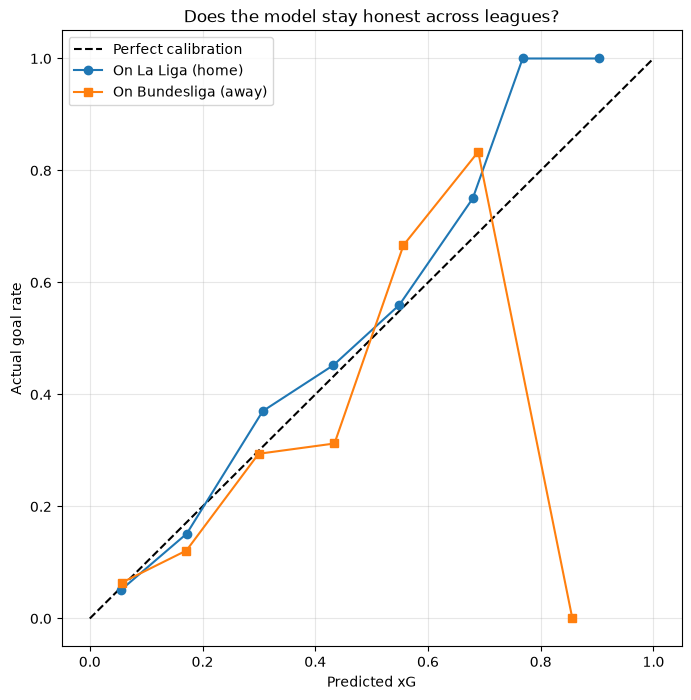

In [8]:
# ---- Is the model still well-calibrated on Bundesliga? ----
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Calculate calibration for La Liga (test set) and Bundesliga
# We reuse the La Liga test predictions to compare fairly
laliga_test_preds = baseline_model.predict_proba(X_test)[:, 1]   # La Liga predictions
ll_true, ll_pred = calibration_curve(y_test, laliga_test_preds, n_bins=8)      # La Liga
bd_true, bd_pred = calibration_curve(y_bundesliga, bundesliga_preds, n_bins=8) # Bundesliga

# Draw both calibration curves on one chart
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')     # the honesty line
plt.plot(ll_pred, ll_true, 'o-', label='On La Liga (home)')       # home league
plt.plot(bd_pred, bd_true, 's-', label='On Bundesliga (away)')    # away league

plt.xlabel('Predicted xG')
plt.ylabel('Actual goal rate')
plt.title('Does the model stay honest across leagues?')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()